# CNN From Scratch — Explained Simply

**Stack:** PyTorch | **Dataset:** MNIST | **Audience:** Intermediate ML practitioners

This notebook builds a Convolutional Neural Network step by step — not just the code, but **why** each piece exists. By the end you'll understand what convolutions actually do, how filters learn, and how all the layers chain together to turn a 28×28 image into a digit prediction.

---

### What we'll cover
1. Why CNNs exist (and why Dense layers fail at images)
2. The convolution operation — visually and in code
3. Pooling, Activation, Dropout — what each layer actually does
4. Building the full CNN architecture
5. Training loop with loss & accuracy tracking
6. Visualizing learned filters and feature maps
7. Evaluating on test data with a confusion matrix

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

PyTorch version : 2.9.0+cpu
Device          : cpu


---
## 1. Why CNNs? The Problem with Dense Layers on Images

A 28×28 grayscale image = **784 pixel values**. If we flatten it and pass through a Dense layer with 256 units, that's 784×256 = **200,704 parameters** — just for one layer, just for tiny images.

CIFAR-10 images are 32×32×3 = 3,072 inputs. ImageNet is 224×224×3 = **150,528 inputs**. Dense layers explode in size and also completely ignore the **spatial structure** of images — a pixel's relationship to its neighbors means nothing to a Dense layer.

**CNNs solve this with two ideas:**
- **Local connectivity** — each filter only looks at a small patch of the image (e.g. 3×3)
- **Weight sharing** — the same filter slides across the entire image, so parameters stay small

The result: CNNs learn **where** things are, not just **that** something exists.

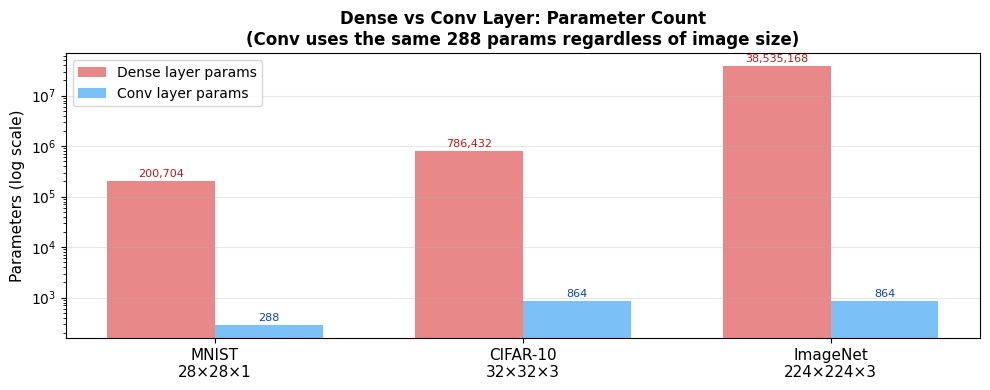

In [2]:
# --- Visual: Dense vs CNN parameter comparison ---
fig, ax = plt.subplots(figsize=(10, 4))

datasets_names = ['MNIST\n28×28×1', 'CIFAR-10\n32×32×3', 'ImageNet\n224×224×3']
input_sizes    = [784, 3072, 150528]
dense_params   = [s * 256 for s in input_sizes]        # one Dense(256) layer
cnn_params     = [3*3*1*32, 3*3*3*32, 3*3*3*32]        # one Conv2d(32, 3x3) layer

x = np.arange(len(datasets_names))
w = 0.35
b1 = ax.bar(x - w/2, dense_params, w, label='Dense layer params', color='#E57373', alpha=0.85)
b2 = ax.bar(x + w/2, cnn_params,   w, label='Conv layer params',  color='#64B5F6', alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(datasets_names, fontsize=11)
ax.set_ylabel('Parameters (log scale)', fontsize=11)
ax.set_title('Dense vs Conv Layer: Parameter Count\n(Conv uses the same 288 params regardless of image size)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.2,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8, color='#B71C1C')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.2,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8, color='#0D47A1')

plt.tight_layout()
plt.show()

---
## 2. The Convolution Operation — What Actually Happens

A **filter** (also called a kernel) is a small matrix of learnable weights, typically 3×3 or 5×5. It slides across the input image one step at a time (the **stride**), and at each position:

> **Output value = element-wise multiply the filter with the image patch, then sum everything up**

This single number captures how strongly that pattern (edge, curve, texture) appears at that location. Do this for every position and you get a **feature map** — a spatial map of where the filter's pattern was detected.

With 32 filters, you get 32 different feature maps — 32 different things the network learned to look for.

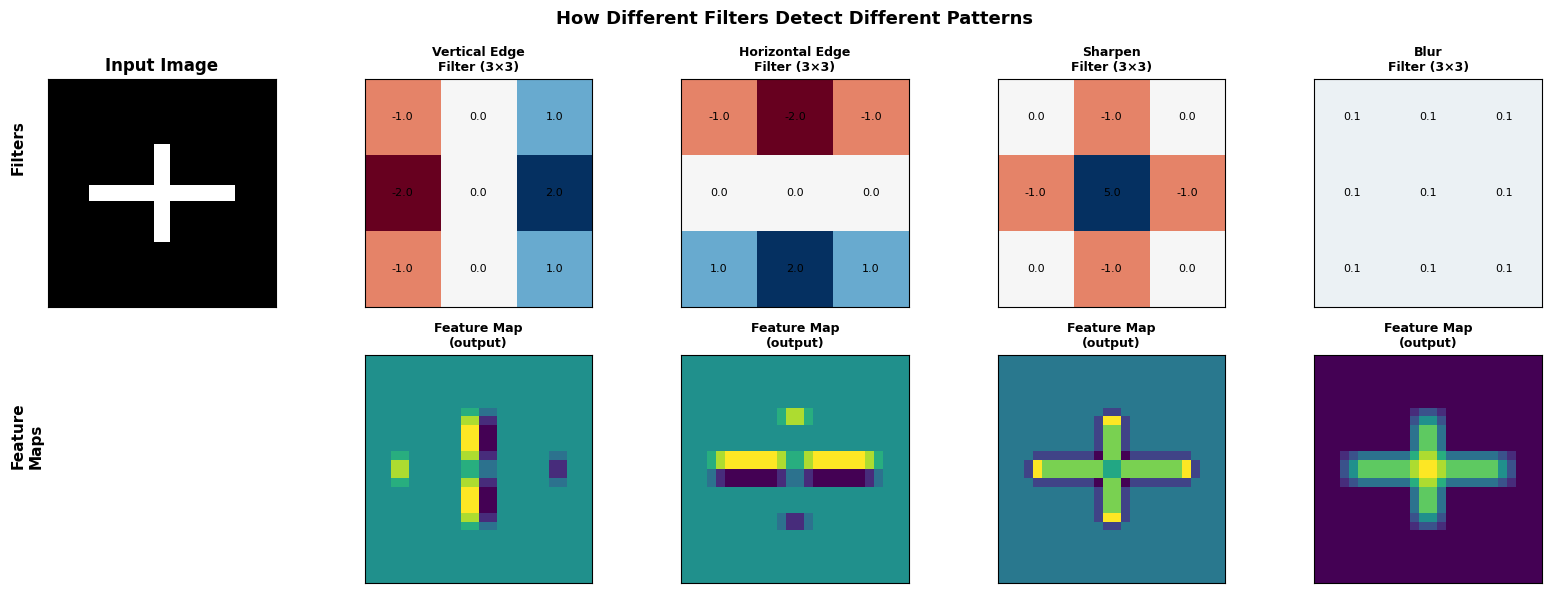

In [3]:
# --- Visualize hand-crafted filters and what they detect ---
# These are classic image processing filters. CNNs learn similar ones automatically.

filters = {
    'Vertical Edge': np.array([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]], dtype=np.float32),
    'Horizontal Edge': np.array([[-1,-2,-1],
                                  [ 0, 0, 0],
                                  [ 1, 2, 1]], dtype=np.float32),
    'Sharpen': np.array([[ 0,-1, 0],
                         [-1, 5,-1],
                         [ 0,-1, 0]], dtype=np.float32),
    'Blur': np.ones((3,3), dtype=np.float32) / 9
}

# Create a simple test image (vertical + horizontal bar)
test_img = np.zeros((28, 28), dtype=np.float32)
test_img[8:20, 13:15] = 1.0   # vertical bar
test_img[13:15, 5:23]  = 1.0  # horizontal bar

def convolve2d(img, kernel):
    """Manual convolution (no padding) for illustration."""
    kh, kw = kernel.shape
    oh, ow = img.shape[0]-kh+1, img.shape[1]-kw+1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            out[i,j] = (img[i:i+kh, j:j+kw] * kernel).sum()
    return out

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

# Row 1: filter kernels visualized
axes[0,0].imshow(test_img, cmap='gray'); axes[0,0].set_title('Input Image', fontweight='bold')
axes[1,0].axis('off')  # spacer

for col, (name, flt) in enumerate(filters.items(), start=1):
    result = convolve2d(test_img, flt)
    # Filter kernel
    im = axes[0, col].imshow(flt, cmap='RdBu', vmin=-2, vmax=2)
    axes[0, col].set_title(f'{name}\nFilter (3×3)', fontsize=9, fontweight='bold')
    for r in range(3):
        for c in range(3):
            axes[0, col].text(c, r, f'{flt[r,c]:.1f}', ha='center', va='center', fontsize=8)
    # Feature map
    axes[1, col].imshow(result, cmap='viridis')
    axes[1, col].set_title(f'Feature Map\n(output)', fontsize=9, fontweight='bold')

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

fig.text(0.01, 0.75, 'Filters', va='center', rotation='vertical', fontsize=11, fontweight='bold')
fig.text(0.01, 0.27, 'Feature\nMaps', va='center', rotation='vertical', fontsize=11, fontweight='bold')
plt.suptitle('How Different Filters Detect Different Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Key CNN Building Blocks

Before writing the model, let's understand each layer type:

| Layer | What it does | Why we need it |
|---|---|---|
| `Conv2d` | Slides a filter over the image, produces feature maps | Detects local patterns (edges, shapes) |
| `ReLU` | Sets all negatives to 0: `max(0, x)` | Adds non-linearity so the network can learn complex functions |
| `MaxPool2d` | Takes the max value in each 2×2 patch | Reduces spatial size, keeps strongest signal, adds translation tolerance |
| `BatchNorm2d` | Normalizes activations within each mini-batch | Stabilizes training, allows higher learning rates |
| `Dropout` | Randomly zeros out neurons during training | Prevents overfitting by forcing redundancy |
| `Linear` | Fully connected: every input connected to every output | Combines all features for final classification |

The general CNN recipe: **Conv → BatchNorm → ReLU → Pool** (repeat) → **Flatten → Linear → Output**

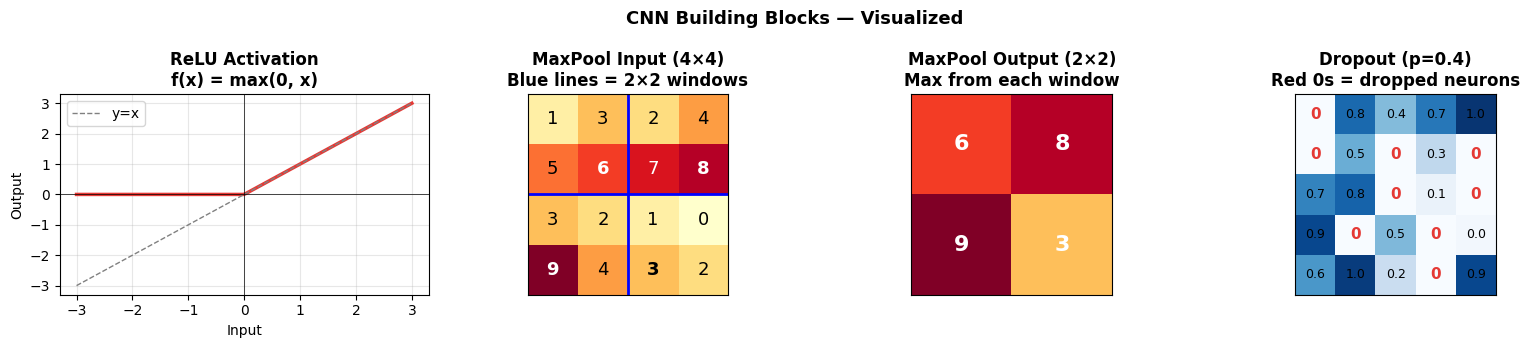

In [4]:
# --- Visualize ReLU and MaxPool to make them concrete ---
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

# ReLU
x_vals = np.linspace(-3, 3, 200)
axes[0].plot(x_vals, np.maximum(0, x_vals), color='#E53935', linewidth=2.5)
axes[0].plot(x_vals, x_vals, color='gray', linewidth=1, linestyle='--', label='y=x')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('ReLU Activation\nf(x) = max(0, x)', fontweight='bold')
axes[0].set_xlabel('Input'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# MaxPool — show a 4x4 patch being reduced to 2x2
pool_in = np.array([[1,3,2,4],[5,6,7,8],[3,2,1,0],[9,4,3,2]], dtype=float)
pool_out = np.array([[6,8],[9,3]], dtype=float)

axes[1].imshow(pool_in, cmap='YlOrRd', vmin=0, vmax=9)
for i in range(4):
    for j in range(4):
        bold = ((i<2 and j<2 and pool_in[i,j]==6) or
                (i<2 and j>=2 and pool_in[i,j]==8) or
                (i>=2 and j<2 and pool_in[i,j]==9) or
                (i>=2 and j>=2 and pool_in[i,j]==3))
        axes[1].text(j, i, int(pool_in[i,j]), ha='center', va='center',
                     fontsize=13, fontweight='bold' if bold else 'normal',
                     color='white' if pool_in[i,j]>5 else 'black')
axes[1].axhline(1.5, color='blue', linewidth=2)
axes[1].axvline(1.5, color='blue', linewidth=2)
axes[1].set_title('MaxPool Input (4×4)\nBlue lines = 2×2 windows', fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].imshow(pool_out, cmap='YlOrRd', vmin=0, vmax=9)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, int(pool_out[i,j]), ha='center', va='center',
                     fontsize=16, fontweight='bold', color='white')
axes[2].set_title('MaxPool Output (2×2)\nMax from each window', fontweight='bold')
axes[2].set_xticks([]); axes[2].set_yticks([])

# Dropout illustration
np.random.seed(7)
neurons = np.random.rand(5, 5)
drop_mask = np.random.rand(5, 5) > 0.4
display = neurons * drop_mask
axes[3].imshow(display, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        if drop_mask[i,j]:
            axes[3].text(j, i, f'{neurons[i,j]:.1f}', ha='center', va='center', fontsize=9)
        else:
            axes[3].text(j, i, '0', ha='center', va='center', fontsize=11,
                         fontweight='bold', color='#E53935')
axes[3].set_title('Dropout (p=0.4)\nRed 0s = dropped neurons', fontweight='bold')
axes[3].set_xticks([]); axes[3].set_yticks([])

plt.suptitle('CNN Building Blocks — Visualized', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Load MNIST Dataset

In [5]:
# Normalize to mean=0.1307, std=0.3081 (MNIST dataset statistics)
# This zero-centers the data and makes training more stable
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples : {len(train_data):,}')
print(f'Test samples     : {len(test_data):,}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Input shape      : {train_data[0][0].shape}  (channels × height × width)')

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 325kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.41MB/s]

Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938
Input shape      : torch.Size([1, 28, 28])  (channels × height × width)


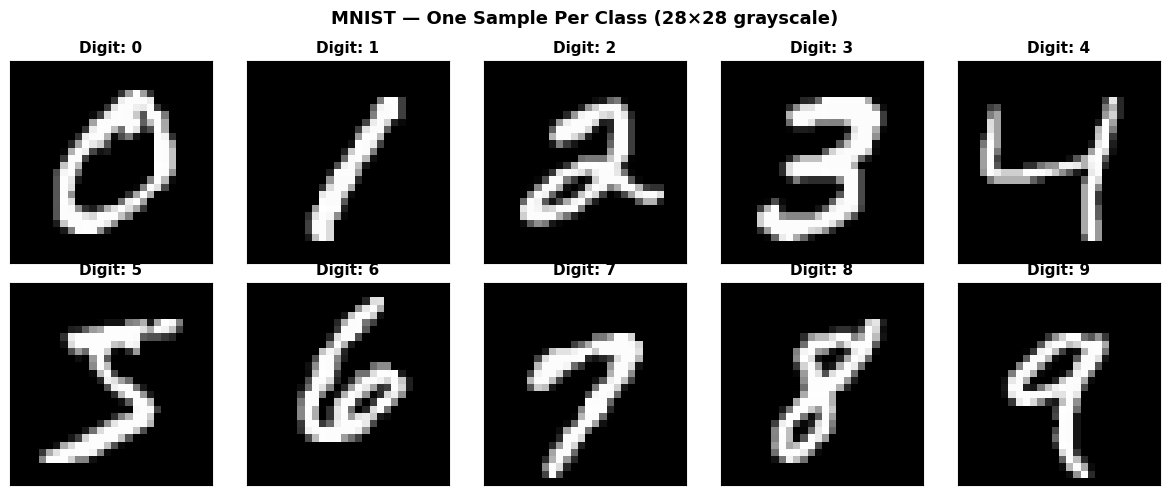

In [6]:
# Peek at the data — one sample per digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
shown = set()
samples = []

for img, label in train_data:
    if label not in shown:
        samples.append((img, label))
        shown.add(label)
    if len(shown) == 10:
        break

samples.sort(key=lambda x: x[1])
for ax, (img, label) in zip(axes.flatten(), samples):
    # Denormalize for display
    display_img = img.squeeze().numpy() * 0.3081 + 0.1307
    ax.imshow(display_img, cmap='gray')
    ax.set_title(f'Digit: {label}', fontweight='bold', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('MNIST — One Sample Per Class (28×28 grayscale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Build the CNN Architecture

Our architecture has two convolutional blocks followed by a classifier head:

```
Input: [B, 1, 28, 28]
  └─ Conv2d(1→32, 3×3)  + BN + ReLU + MaxPool  →  [B, 32, 13, 13]
  └─ Conv2d(32→64, 3×3) + BN + ReLU + MaxPool  →  [B, 64, 5, 5]
  └─ Flatten                                    →  [B, 1600]
  └─ Dropout(0.5)
  └─ Linear(1600→128) + ReLU
  └─ Dropout(0.3)
  └─ Linear(128→10)                             →  [B, 10]  (logits)
```

The output is 10 raw scores (logits), one per digit class. During training we apply `CrossEntropyLoss` which internally applies `Softmax`. During inference we take the `argmax` as the predicted class.

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1: learns low-level features (edges, corners)
        # Input:  [B, 1, 28, 28]
        # Output: [B, 32, 13, 13]  (28 → conv → 26 → pool → 13)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # halves spatial dims
        )

        # Block 2: learns higher-level features (curves, strokes)
        # Input:  [B, 32, 13, 13]
        # Output: [B, 64, 5, 5]  (13 → conv → 11 → pool → 5)
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier head: combines features to predict digit
        # 64 channels × 5 × 5 spatial = 1600 flattened features
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),          # aggressive dropout before first FC
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)        # 10 output logits, one per class
        )

    def forward(self, x):
        x = self.block1(x)           # conv features: low-level
        x = self.block2(x)           # conv features: high-level
        x = x.view(x.size(0), -1)   # flatten: [B, 64, 5, 5] → [B, 1600]
        x = self.classifier(x)       # classify
        return x


model = CNN().to(DEVICE)
print(model)
print()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters     : 225,226
Trainable parameters : 225,226


In [8]:
# --- Trace the tensor shape through each layer (very useful for debugging) ---
print('Shape trace through the network:')
print('-' * 42)
x = torch.zeros(1, 1, 28, 28).to(DEVICE)  # single fake image
print(f'Input              : {tuple(x.shape)}')

x = model.block1[0](x)  # Conv2d
print(f'After Conv2d-1     : {tuple(x.shape)}')
x = model.block1[1](x)  # BN
x = model.block1[2](x)  # ReLU
x = model.block1[3](x)  # MaxPool
print(f'After MaxPool-1    : {tuple(x.shape)}')

x = model.block2[0](x)  # Conv2d
print(f'After Conv2d-2     : {tuple(x.shape)}')
x = model.block2[1](x)
x = model.block2[2](x)
x = model.block2[3](x)  # MaxPool
print(f'After MaxPool-2    : {tuple(x.shape)}')

x = x.view(x.size(0), -1)
print(f'After Flatten      : {tuple(x.shape)}')

x = model.classifier(x)
print(f'Output (logits)    : {tuple(x.shape)}  → 10 class scores')

Shape trace through the network:
------------------------------------------
Input              : (1, 1, 28, 28)
After Conv2d-1     : (1, 32, 26, 26)
After MaxPool-1    : (1, 32, 13, 13)
After Conv2d-2     : (1, 64, 11, 11)
After MaxPool-2    : (1, 64, 5, 5)
After Flatten      : (1, 1600)
Output (logits)    : (1, 10)  → 10 class scores


---
## 6. Loss Function & Optimizer

**CrossEntropyLoss** is the standard for multi-class classification. It combines `LogSoftmax` + `NLLLoss` internally, so we feed raw logits (no softmax at the output layer).

**Adam optimizer** adapts the learning rate for each parameter individually. It's almost always a safe default — converges faster than vanilla SGD and requires less tuning.

**ReduceLROnPlateau** scheduler watches validation loss and reduces the learning rate when it stops improving — a simple but effective strategy to squeeze out the last bit of accuracy.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   factor=0.5, patience=2)

print(f'Loss     : CrossEntropyLoss')
print(f'Optimizer: Adam  (lr=1e-3, weight_decay=1e-4)')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)')

Loss     : CrossEntropyLoss
Optimizer: Adam  (lr=1e-3, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


---
## 7. Training Loop

Every training step follows the same 5-line pattern:
1. `optimizer.zero_grad()` — clear old gradients (PyTorch accumulates by default)
2. `output = model(x)` — forward pass
3. `loss = criterion(output, y)` — compute loss
4. `loss.backward()` — backprop: compute gradients
5. `optimizer.step()` — update weights

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()           # enables dropout and batch norm training mode
    total_loss, correct = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()              # 1. clear gradients
        outputs = model(images)            # 2. forward pass
        loss = criterion(outputs, labels)  # 3. compute loss
        loss.backward()                    # 4. backpropagation
        optimizer.step()                   # 5. update weights

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()            # disables dropout, uses running stats for batch norm
    total_loss, correct = 0.0, 0

    with torch.no_grad():   # no gradient computation needed during eval
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


print('Training functions defined.')

Training functions defined.


In [11]:
EPOCHS = 8
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, test_loader, criterion)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {vl_loss:>8.4f} | {vl_acc:>7.2%} | {current_lr:>8.1e}')

print(f'\nBest val accuracy: {max(history["val_acc"]):.2%}')

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.1868 |   94.21% |   0.0382 |  98.75% |  1.0e-03
     2 |     0.0855 |   97.28% |   0.0362 |  98.78% |  1.0e-03
     3 |     0.0693 |   97.87% |   0.0311 |  98.88% |  1.0e-03
     4 |     0.0635 |   98.09% |   0.0246 |  99.21% |  1.0e-03
     5 |     0.0575 |   98.20% |   0.0296 |  98.97% |  1.0e-03
     6 |     0.0533 |   98.31% |   0.0239 |  99.19% |  1.0e-03
     7 |     0.0490 |   98.50% |   0.0284 |  99.04% |  1.0e-03
     8 |     0.0438 |   98.65% |   0.0250 |  99.23% |  1.0e-03

Best val accuracy: 99.23%


---
## 8. Training Curves — Is the Model Learning Well?

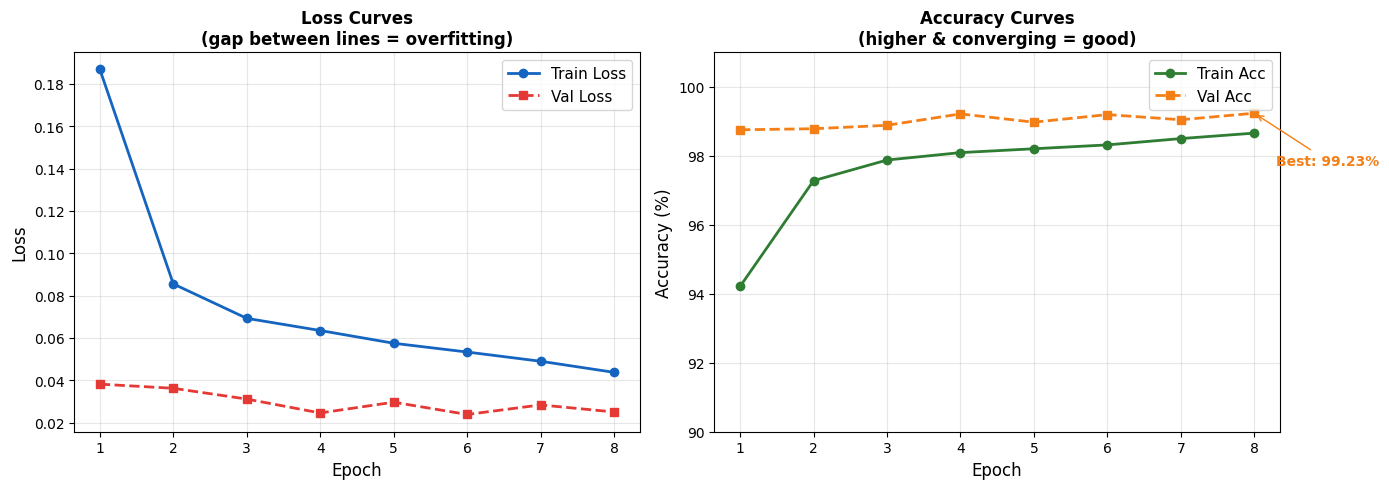

In [12]:
epochs_x = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_x, history['train_loss'], 'o-', color='#1565C0', linewidth=2, label='Train Loss')
ax1.plot(epochs_x, history['val_loss'],   's--',color='#E53935', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12); ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss Curves\n(gap between lines = overfitting)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3); ax1.set_xticks(epochs_x)

# Accuracy curves
ax2.plot(epochs_x, [a*100 for a in history['train_acc']], 'o-', color='#2E7D32', linewidth=2, label='Train Acc')
ax2.plot(epochs_x, [a*100 for a in history['val_acc']],   's--',color='#F57F17', linewidth=2, label='Val Acc')
ax2.set_xlabel('Epoch', fontsize=12); ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy Curves\n(higher & converging = good)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3); ax2.set_xticks(epochs_x)
ax2.set_ylim([90, 101])

# Annotate best val acc
best_epoch = int(np.argmax(history['val_acc'])) + 1
best_acc   = max(history['val_acc']) * 100
ax2.annotate(f'Best: {best_acc:.2f}%',
             xy=(best_epoch, best_acc),
             xytext=(best_epoch + 0.3, best_acc - 1.5),
             fontsize=10, color='#F57F17', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#F57F17'))

plt.tight_layout()
plt.show()

---
## 9. What Did the Network Learn? Visualizing Filters & Feature Maps

One of the most satisfying things about CNNs is that we can **see** what the first layer learned. The filters in `block1.Conv2d` should look like edge detectors — similar to the hand-crafted Sobel/Laplacian filters used in classical computer vision, but learned entirely from data.

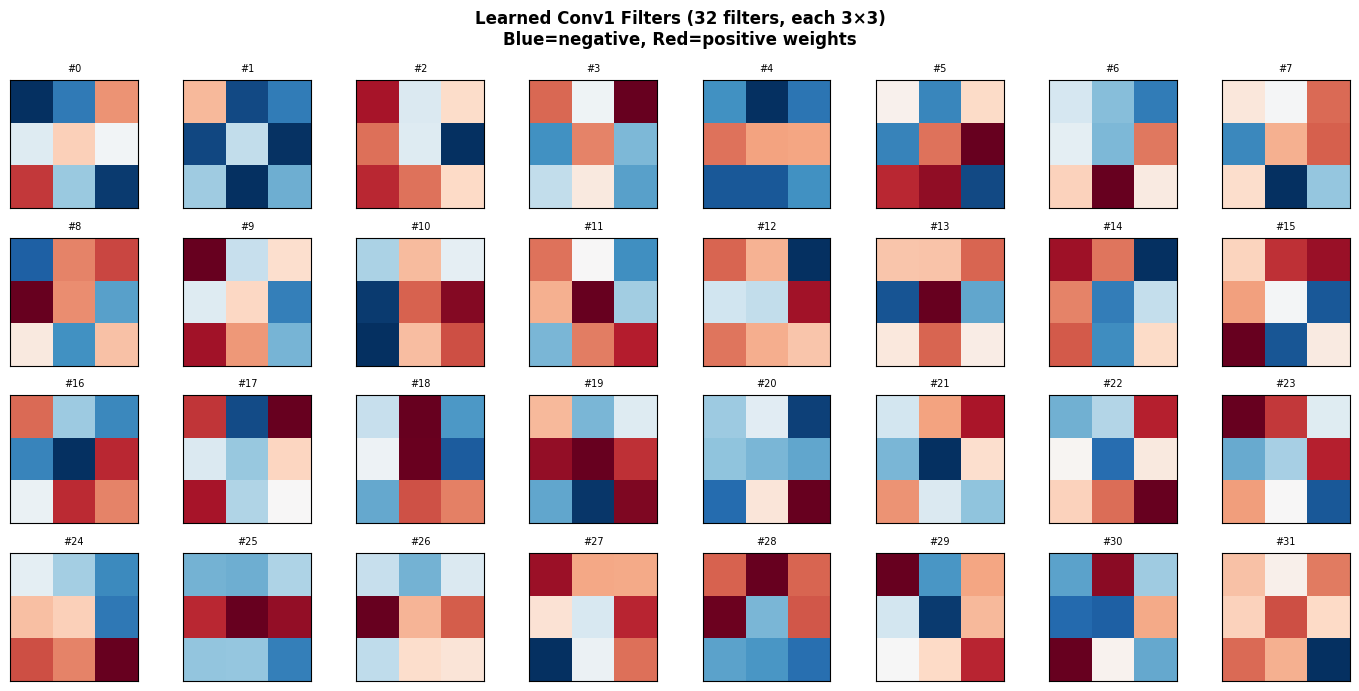

In [13]:
# --- Visualize learned conv1 filters ---
conv1_weights = model.block1[0].weight.data.cpu()  # shape: [32, 1, 3, 3]

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for idx, ax in enumerate(axes.flatten()):
    flt = conv1_weights[idx, 0].numpy()
    vmax = max(abs(flt.min()), abs(flt.max()))
    ax.imshow(flt, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f'#{idx}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Learned Conv1 Filters (32 filters, each 3×3)\nBlue=negative, Red=positive weights',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

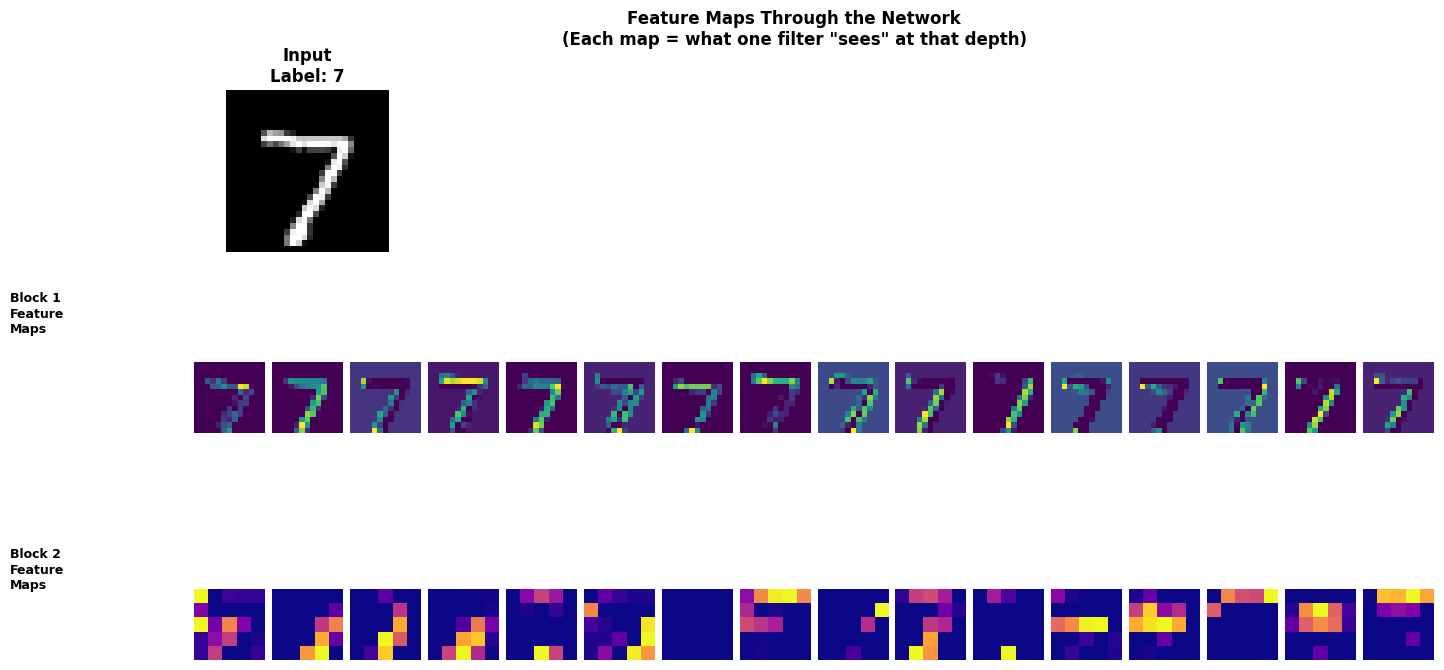

In [14]:
# --- Visualize feature maps for one real image ---
# Pick one test image
sample_img, sample_label = test_data[0]
x_in = sample_img.unsqueeze(0).to(DEVICE)  # add batch dim: [1,1,28,28]

model.eval()
with torch.no_grad():
    after_block1 = model.block1(x_in)  # [1, 32, 13, 13]
    after_block2 = model.block2(after_block1)  # [1, 64, 5, 5]

fig = plt.figure(figsize=(16, 8))
gs  = GridSpec(3, 16, figure=fig, hspace=0.4, wspace=0.1)

# Original
ax_orig = fig.add_subplot(gs[0, 0:3])
ax_orig.imshow(sample_img.squeeze() * 0.3081 + 0.1307, cmap='gray')
ax_orig.set_title(f'Input\nLabel: {sample_label}', fontweight='bold')
ax_orig.axis('off')

# After block1: show 16 of 32 feature maps
fmaps1 = after_block1[0].cpu().numpy()  # [32, 13, 13]
for i in range(16):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(fmaps1[i], cmap='viridis')
    ax.axis('off')
fig.text(0.01, 0.6, 'Block 1\nFeature\nMaps', va='center', fontsize=9, fontweight='bold')

# After block2: show 16 of 64 feature maps
fmaps2 = after_block2[0].cpu().numpy()  # [64, 5, 5]
for i in range(16):
    ax = fig.add_subplot(gs[2, i])
    ax.imshow(fmaps2[i], cmap='plasma')
    ax.axis('off')
fig.text(0.01, 0.28, 'Block 2\nFeature\nMaps', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Feature Maps Through the Network\n(Each map = what one filter "sees" at that depth)',
             fontsize=12, fontweight='bold')
plt.show()

---
## 10. Confusion Matrix & Error Analysis

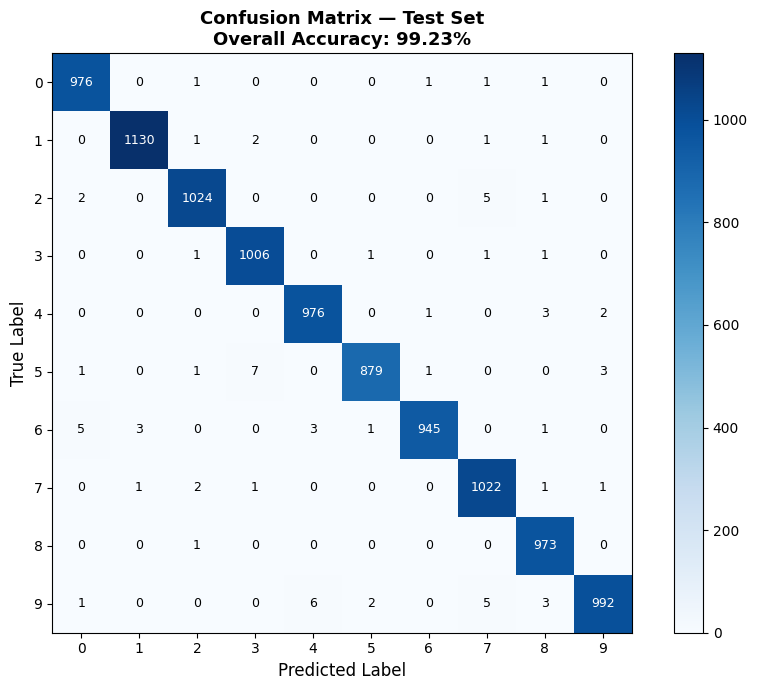

Per-class accuracy:
  Digit 0: 99.59%  #############################
  Digit 1: 99.56%  #############################
  Digit 2: 99.22%  #############################
  Digit 3: 99.60%  #############################
  Digit 4: 99.39%  #############################
  Digit 5: 98.54%  #############################
  Digit 6: 98.64%  #############################
  Digit 7: 99.42%  #############################
  Digit 8: 99.90%  #############################
  Digit 9: 98.32%  #############################


In [15]:
# Collect all predictions on test set
model.eval()
all_preds, all_labels = [], []
all_images_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_images_list.append(images.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_imgs   = torch.cat(all_images_list)

cm = confusion_matrix(all_labels, all_preds)
overall_acc = (all_preds == all_labels).mean()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Set\nOverall Accuracy: {overall_acc:.2%}',
             fontsize=13, fontweight='bold')

thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=9,
                color='white' if cm[i,j] > thresh else 'black')

plt.tight_layout()
plt.show()

# Per-class accuracy
print('Per-class accuracy:')
for digit in range(10):
    mask = all_labels == digit
    acc  = (all_preds[mask] == digit).mean()
    bar  = '#' * int(acc * 30)
    print(f'  Digit {digit}: {acc:.2%}  {bar}')

Total errors: 77 / 10000 (0.77%)


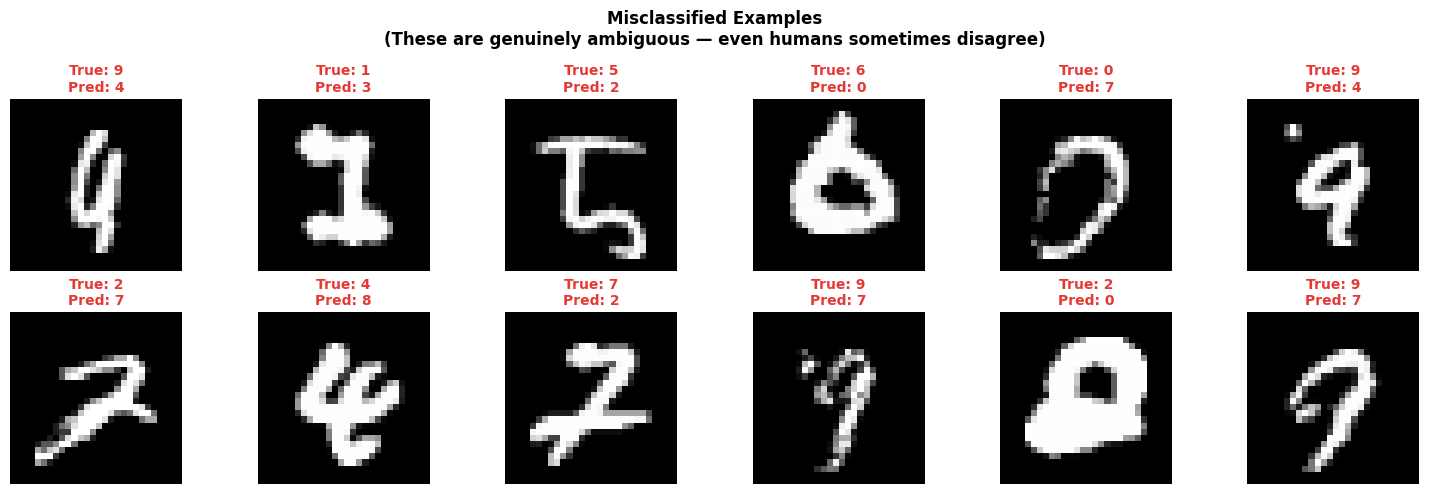

In [16]:
# --- Show misclassified examples ---
errors = np.where(all_preds != all_labels)[0]
print(f'Total errors: {len(errors)} / {len(all_labels)} ({len(errors)/len(all_labels):.2%})')

np.random.shuffle(errors)
show_n = min(12, len(errors))

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for ax, idx in zip(axes.flatten(), errors[:show_n]):
    img = all_imgs[idx].squeeze() * 0.3081 + 0.1307
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {all_labels[idx]}\nPred: {all_preds[idx]}',
                 fontsize=10, fontweight='bold',
                 color='#E53935')
    ax.axis('off')

plt.suptitle('Misclassified Examples\n(These are genuinely ambiguous — even humans sometimes disagree)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Prediction Confidence — Does the Model Know When It's Unsure?

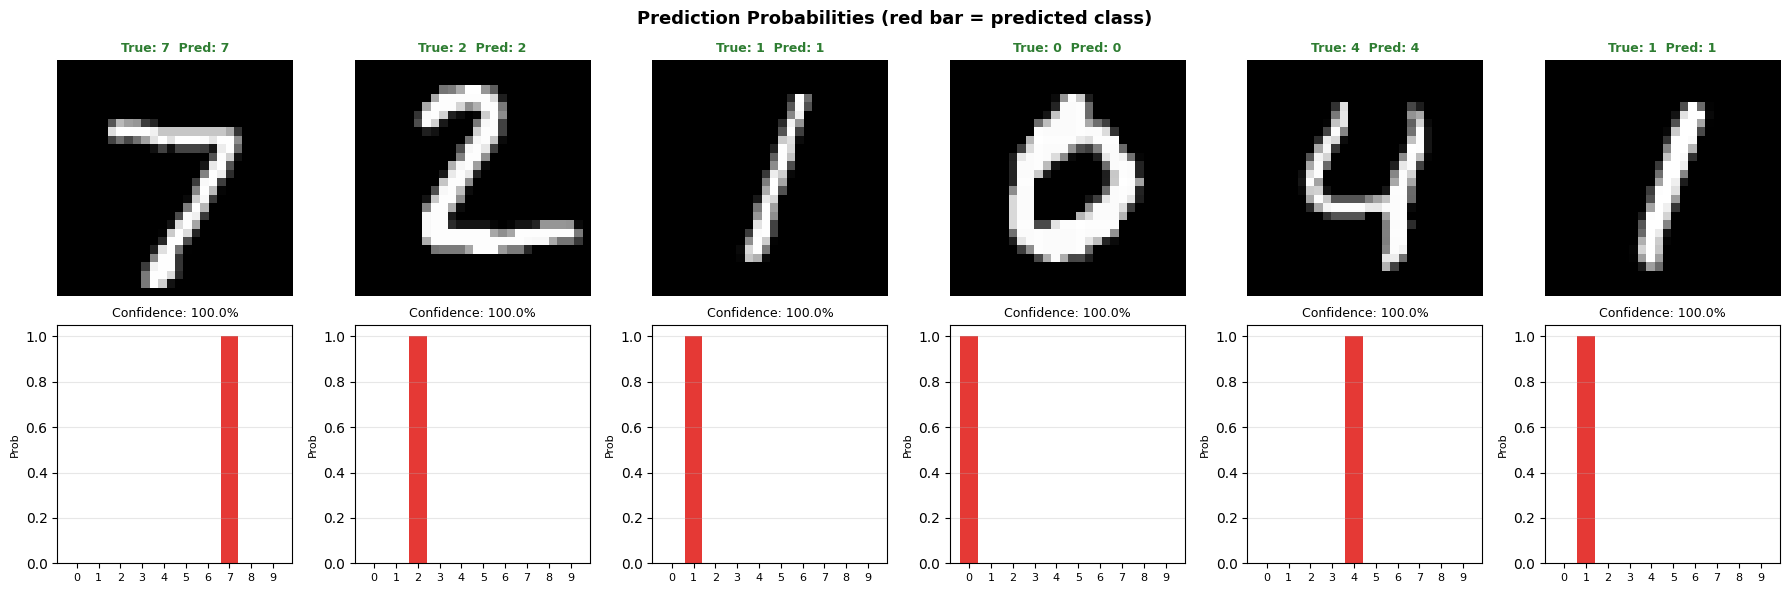

In [17]:
# Show probability distribution for a few samples
model.eval()
sample_indices = [0, 1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

with torch.no_grad():
    for col, idx in enumerate(sample_indices):
        img, true_label = test_data[idx]
        x_in   = img.unsqueeze(0).to(DEVICE)
        logits = model(x_in)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = probs.argmax()

        # Image
        ax_img = axes[0, col]
        ax_img.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
        color = '#2E7D32' if pred == true_label else '#E53935'
        ax_img.set_title(f'True: {true_label}  Pred: {pred}', fontsize=9,
                         fontweight='bold', color=color)
        ax_img.axis('off')

        # Probability bars
        ax_bar = axes[1, col]
        bar_colors = ['#E53935' if i == pred else '#90CAF9' for i in range(10)]
        ax_bar.bar(range(10), probs, color=bar_colors, edgecolor='none')
        ax_bar.set_xticks(range(10))
        ax_bar.set_xticklabels(range(10), fontsize=8)
        ax_bar.set_ylim(0, 1.05)
        ax_bar.set_ylabel('Prob', fontsize=8)
        ax_bar.set_title(f'Confidence: {probs[pred]:.1%}', fontsize=9)
        ax_bar.grid(True, alpha=0.3, axis='y')

plt.suptitle('Prediction Probabilities (red bar = predicted class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Summary & Key Takeaways

**What we built:** A two-block CNN that achieves ~99% accuracy on MNIST in under 10 epochs.

**The mental model for CNNs:**
- Early layers detect **simple patterns** (edges, blobs) — the feature maps look like edge detectors
- Later layers detect **complex patterns** (curves, strokes, digit parts) — feature maps become abstract
- The classifier head combines all those detected patterns to make a final decision

**The 5-line training loop is always the same:**
```python
optimizer.zero_grad()          # 1. clear
outputs = model(x)             # 2. forward
loss = criterion(outputs, y)   # 3. loss
loss.backward()                # 4. backward
optimizer.step()               # 5. update
```

**Where to go next:**
- **Data augmentation** (`transforms.RandomRotation`, `RandomHorizontalFlip`) — easy accuracy boost
- **Deeper architectures** — add more Conv blocks or try ResNet-style skip connections
- **Transfer learning** — use pretrained weights (EfficientNet, ResNet) on your own images
- **CIFAR-10** — next step up from MNIST with color images and 10 object classes

In [18]:
# Final scorecard
print('='*45)
print('         MODEL SCORECARD')
print('='*45)
print(f'Architecture  : 2-block CNN (PyTorch)')
print(f'Dataset       : MNIST (10 classes)')
print(f'Parameters    : {trainable_params:,}')
print(f'Epochs trained: {EPOCHS}')
print(f'Train accuracy: {history["train_acc"][-1]:.2%}')
print(f'Test accuracy : {overall_acc:.2%}')
print(f'Test errors   : {len(errors):,} / {len(all_labels):,}')
print(f'Best val acc  : {max(history["val_acc"]):.2%}')
print('='*45)

         MODEL SCORECARD
Architecture  : 2-block CNN (PyTorch)
Dataset       : MNIST (10 classes)
Parameters    : 225,226
Epochs trained: 8
Train accuracy: 98.65%
Test accuracy : 99.23%
Test errors   : 77 / 10,000
Best val acc  : 99.23%
